In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

In [4]:
df = pd.read_csv("./diamonds.csv")

## 1. Understanding the dataset

In [5]:
df.shape

(53940, 10)

In [6]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price',
       'length_mm', 'width_mm', 'depth_mm'],
      dtype='str')

In [9]:
df.head()

,carat,cut,color,clarity,depth,table,price,length_mm,width_mm,depth_mm
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [7]:
df.isnull().sum()

carat        0
cut          0
color        0
clarity      0
depth        0
table        0
price        0
length_mm    0
width_mm     0
depth_mm     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(146)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   carat      53940 non-null  float64
 1   cut        53940 non-null  str    
 2   color      53940 non-null  str    
 3   clarity    53940 non-null  str    
 4   depth      53940 non-null  float64
 5   table      53940 non-null  float64
 6   price      53940 non-null  int64  
 7   length_mm  53940 non-null  float64
 8   width_mm   53940 non-null  float64
 9   depth_mm   53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


In [11]:
df.describe()

,carat,depth,table,price,length_mm,width_mm,depth_mm
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


## 2. Dropping the duplicated values

In [25]:
dfcopy = df.drop_duplicates()

In [14]:
dfcopy.duplicated().sum()

np.int64(0)

## 3. Outlier analysis

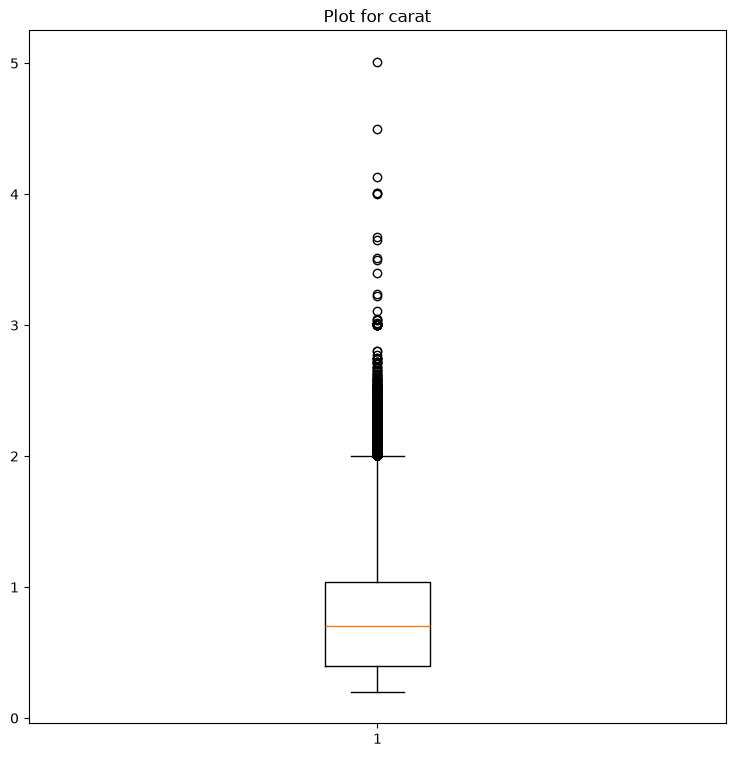

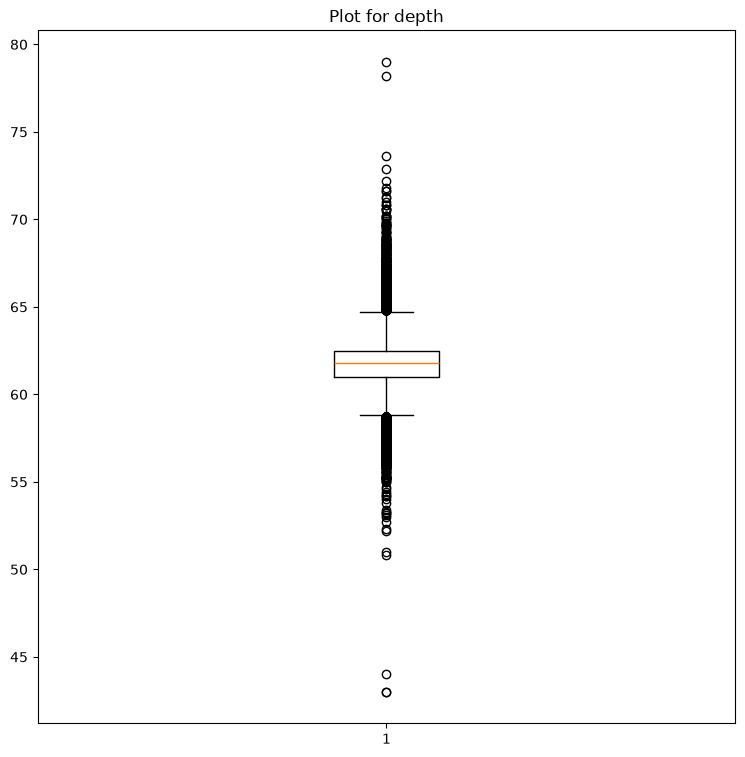

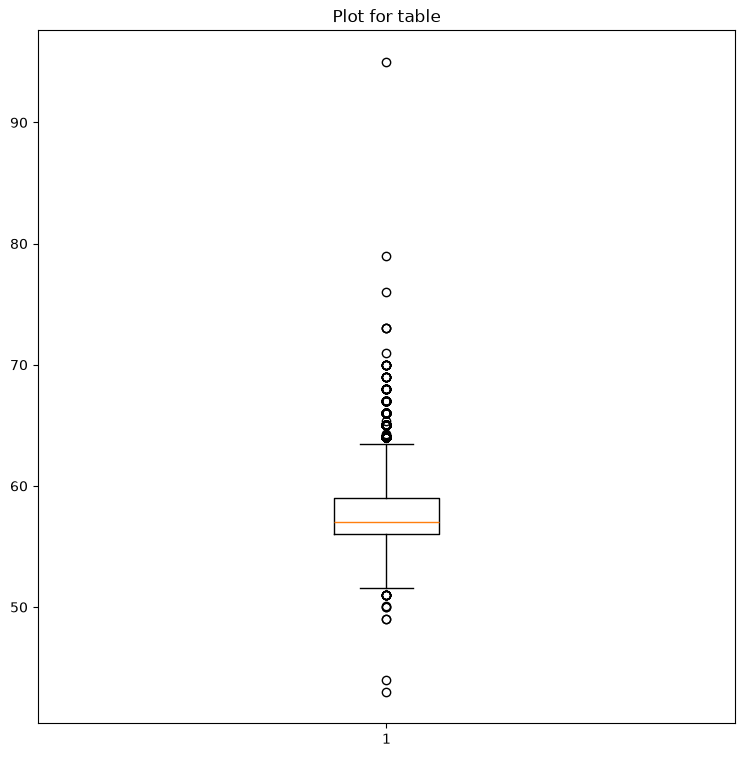

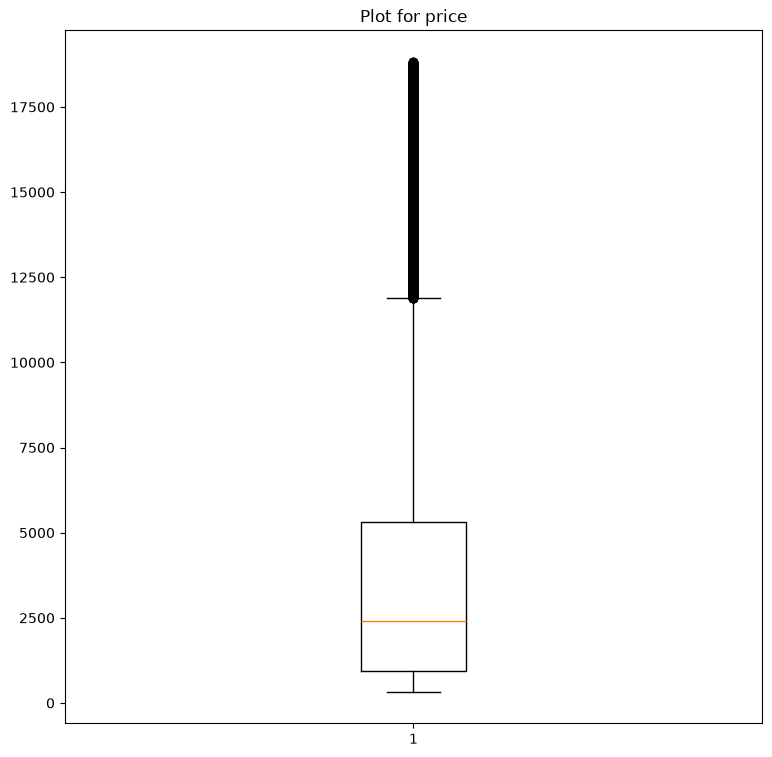

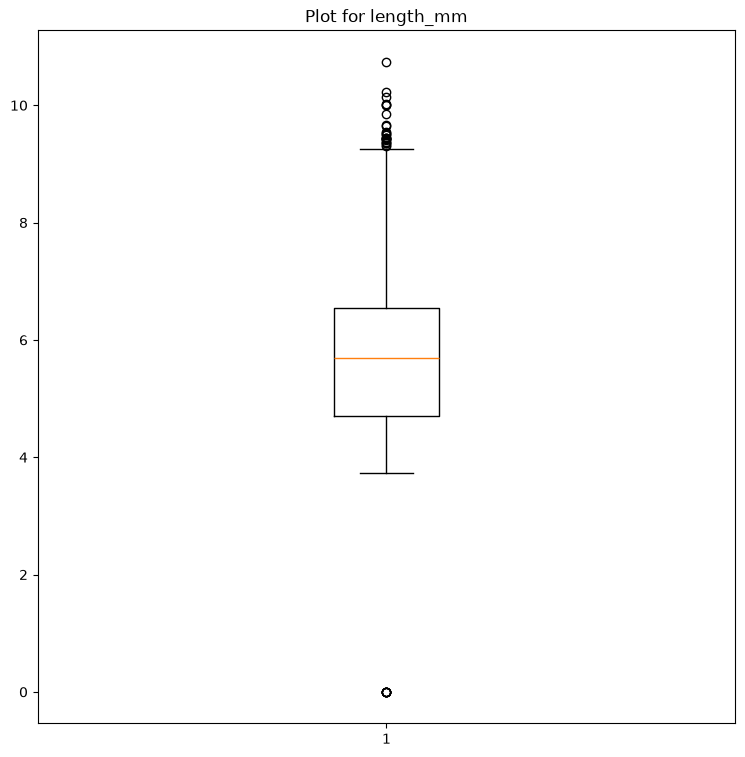

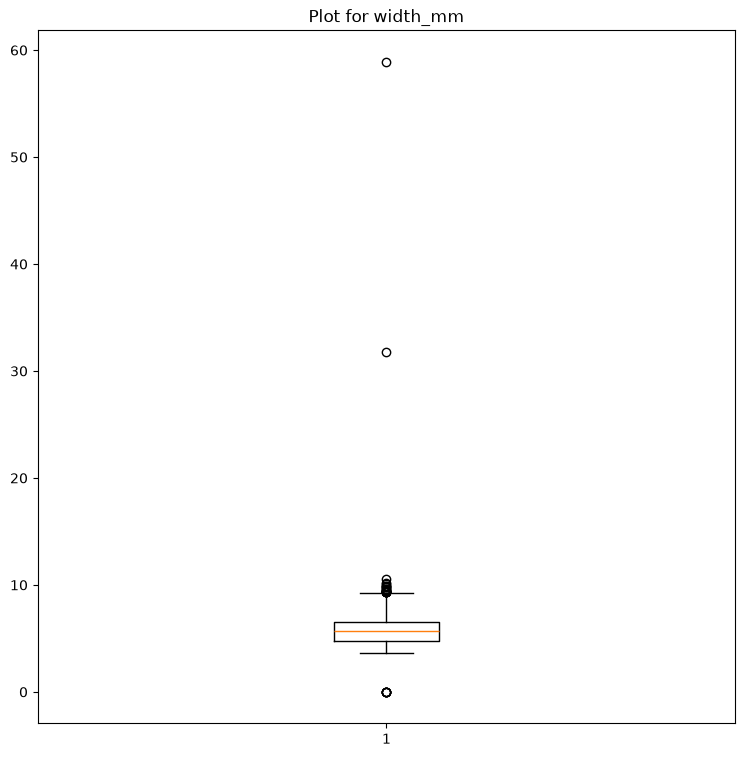

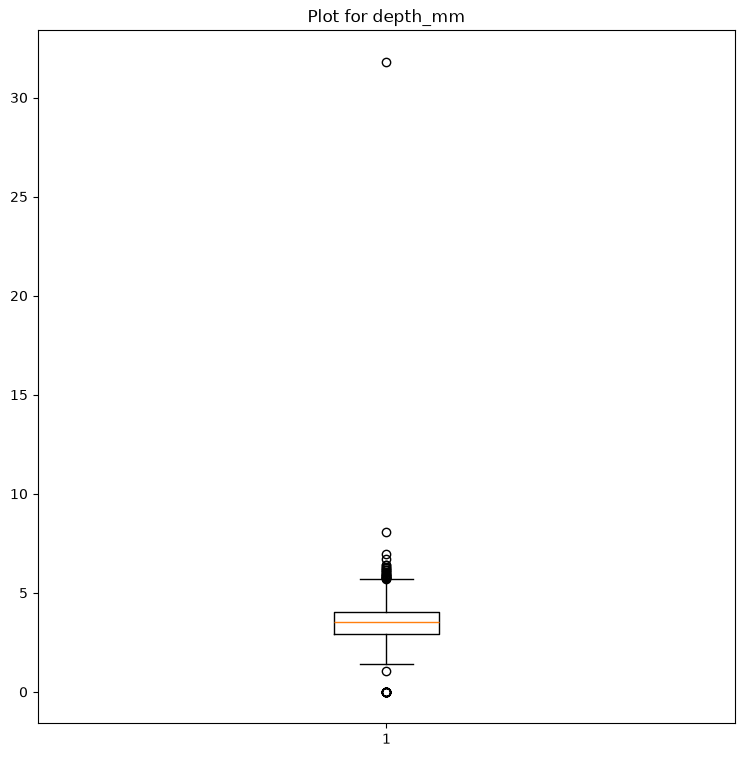

In [15]:
for col in dfcopy.select_dtypes(include='number'):
    plt.figure(figsize=(9,9))
    plt.boxplot(x=dfcopy[col])
    plt.title(f"Plot for {col}")
    plt.show()

#### Using IQR analysis to check the quantity outliers

In [19]:
iqr_counts = {}

for col in dfcopy.select_dtypes(include='number'):
    Q1 = dfcopy[col].quantile(0.25)
    Q3 = dfcopy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit, upper_limit = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    iqr_counts[col] = int(((dfcopy[col] < lower_limit) | (dfcopy[col] > upper_limit)).sum())

pd.DataFrame({ "IQR counts": iqr_counts })

,IQR counts
carat,1873
depth,2525
table,604
price,3523
length_mm,31
width_mm,28
depth_mm,48


## 4. Checking the relation of the numerical columns

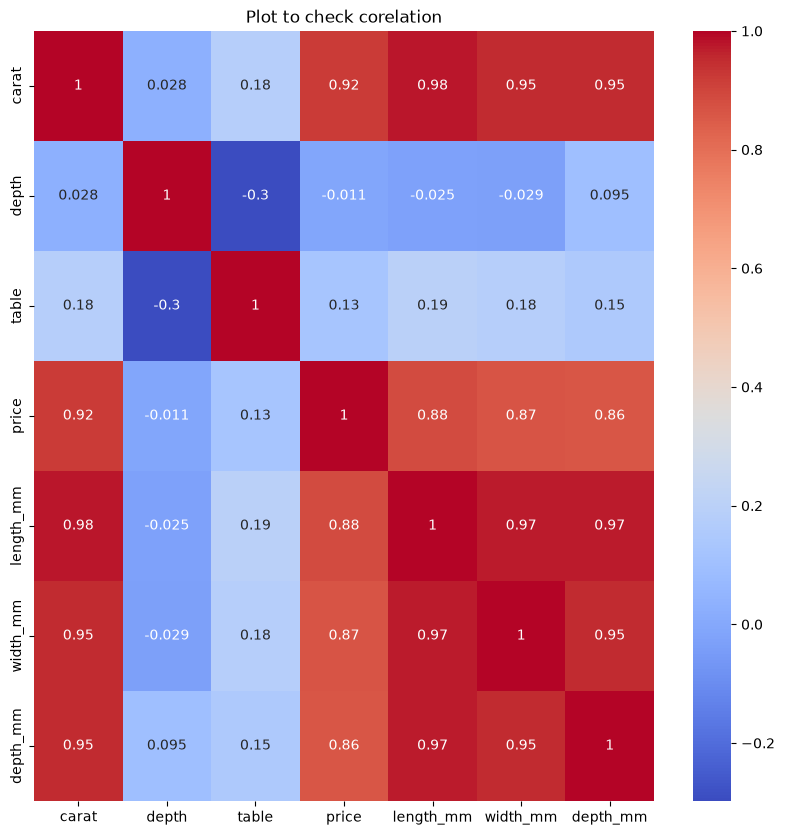

In [20]:
corr = dfcopy.select_dtypes(include='number').corr()

plt.figure(figsize=(10,10))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Plot to check corelation")
plt.show()

There are many significant relationships that exist and are same as the main buisness logic could expect

## 5. Encoding the categorical columns
- clarity
- color
- cut

In [23]:
dfcopy["cut"].unique()

<StringArray>
['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Length: 5, dtype: str

In [27]:
dfcopy = pd.get_dummies(dfcopy, columns=["cut", "color", "clarity"], drop_first=True)

dfcopy.info()

<class 'pandas.DataFrame'>
Index: 53794 entries, 0 to 53939
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   carat          53794 non-null  float64
 1   depth          53794 non-null  float64
 2   table          53794 non-null  float64
 3   price          53794 non-null  int64  
 4   length_mm      53794 non-null  float64
 5   width_mm       53794 non-null  float64
 6   depth_mm       53794 non-null  float64
 7   cut_Good       53794 non-null  bool   
 8   cut_Ideal      53794 non-null  bool   
 9   cut_Premium    53794 non-null  bool   
 10  cut_Very Good  53794 non-null  bool   
 11  color_E        53794 non-null  bool   
 12  color_F        53794 non-null  bool   
 13  color_G        53794 non-null  bool   
 14  color_H        53794 non-null  bool   
 15  color_I        53794 non-null  bool   
 16  color_J        53794 non-null  bool   
 17  clarity_IF     53794 non-null  bool   
 18  clarity_SI1    53794 n

## 6. Preparing the data for the model

In [28]:
X = dfcopy.drop("price", axis=1)
y = dfcopy["price"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(43035, 23)
(10759, 23)
(43035,)
(10759,)


## 7. Training the model

In [49]:
model = RandomForestRegressor(
    random_state= 42,
    n_estimators= 600,
    bootstrap= True,
    max_features='sqrt',
    max_depth=16,
    min_samples_leaf=6,
    min_samples_split=14
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",16
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",14
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",6
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease

## 8. Checking the metrics of the model

In [50]:
y_pred = model.predict(X_test)

print("R2 score: ", r2_score(y_test, y_pred))
print("Mean absolute error: ", mean_absolute_error(y_test, y_pred))
print("Mean squared error: ", mean_squared_error(y_test, y_pred))
print("Root mean squared error: ", root_mean_squared_error(y_test, y_pred))

R2 score:  0.9630119516729343
Mean absolute error:  374.4176187521983
Mean squared error:  563774.4298521609
Root mean squared error:  750.8491392098421


In [52]:
dfcopy.describe(include="all")

,carat,depth,table,price,length_mm,width_mm,depth_mm,cut_Good,cut_Ideal,cut_Premium,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
count,53794.00000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794,53794,53794,...,53794,53794,53794,53794,53794,53794,53794,53794,53794,53794
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,...,2,2,2,2,2,2,2,2,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,...,False,False,False,False,False,False,False,False,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48903,32306,40046,...,45522,48387,50992,52010,40762,44644,45638,41565,50147,48738
mean,0.79778,61.748080,57.458109,3933.065082,5.731214,5.734653,3.538714,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.47339,1.429909,2.233679,3988.114460,1.120695,1.141209,0.705037,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.20000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.40000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.70000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.04000,62.500000,59.000000,5326.750000,6.540000,6.540000,4.030000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 9. Checking the prediction of the model

In [53]:
# 1. Define the input data for a single diamond
# Using the median (50%) values from your summary table for numericals
input_data = {
    # Numerical Features
    'carat': [0.70],
    'depth': [61.80],
    'table': [57.00],
    'length_mm': [5.70],
    'width_mm': [5.71],
    'depth_mm': [3.53],
    
    # Cut: Assuming 'Ideal' (Set cut_Ideal to True, rest to False)
    # Note: If all are False, the model interprets it as the dropped category (e.g., 'Fair')
    'cut_Good': [False],
    'cut_Ideal': [True],
    'cut_Premium': [False],
    'cut_Very Good': [False], # Inferred from standard 5-cut tiers
    
    # Color: Assuming 'H' (Set color_H to True, rest to False)
    'color_E': [False], # Inferred
    'color_F': [False], # Inferred
    'color_G': [False], # Inferred
    'color_H': [True],
    'color_I': [False],
    'color_J': [False],
    
    # Clarity: Assuming 'VS1' (Set clarity_VS1 to True, rest False)
    'clarity_IF': [False],
    'clarity_SI1': [False],
    'clarity_SI2': [False],
    'clarity_VS1': [True],
    'clarity_VS2': [False],
    'clarity_VVS1': [False],
    'clarity_VVS2': [False]
}

# 2. Convert to Pandas DataFrame
inference_df = pd.DataFrame(input_data)

predicted_price = model.predict(inference_df)
print(f"Predicted Price: ${predicted_price[0]:.2f}")

# 3. Ensure the exact column order matches your training data (minus price)
# If your model complains about feature names/order, enforcing it like this prevents errors.
# expected_columns = [
#     'carat', 'depth', 'table', 'length_mm', 'width_mm', 'depth_mm',
#     'cut_Good', 'cut_Ideal', 'cut_Premium', 'cut_Very Good',
#     'color_E', 'color_F', 'color_G', 'color_H', 'color_I', 'color_J',
#     'clarity_IF', 'clarity_SI1', 'clarity_SI2', 'clarity_VS1', 'clarity_VS2', 
#     'clarity_VVS1', 'clarity_VVS2'
# ]

# Reorder columns to match training schema strictly
# inference_df = inference_df[expected_columns]

# 4. Run prediction (Assuming your trained Random Forest is named 'rf_model')
# predicted_price = rf_model.predict(inference_df)
# print(f"Predicted Price: ${predicted_price[0]:.2f}")

# display(inference_df)

Predicted Price: $2855.71


In [54]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
}).reset_index(drop=True)

print(comparison)

   Actual    Predicted
0    1435  1977.611428
1    3584  3645.023437
2    1851  1930.062990
3    1590  1656.818172
4    5690  5675.875868
5     596   716.509520
6     492   574.005562
7    2063  2276.201160
8     970  1045.263482
9    4796  4744.287130
